In [1]:
import os
import pandas as pd
import numpy as np
import json

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

import scipy.stats as stats
from collections import Counter
import pingouin as pg

import random

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
os.getcwd()

'/Users/yilingyun/Documents/WorkInProgress/Charade/latent-force-model-project/human/behavioralExpDataAndAnalysis/exp2'

# Helper functions

In [3]:
def parse_array_from_string (row):
    row = row.options.replace("\'", "\"")
    row = json.loads(row)
    return row

In [4]:
def get_simMat(row, decisionMat, counterMat, matTitle):
    # only fill in the upper triangle
    leftIndex = matTitle.index(row.options[0])
    middleIndex = matTitle.index(row.options[1])
    rightIndex = matTitle.index(row.options[2])

    if leftIndex < middleIndex:
        smallerIndexItem = row.options[0]
        largerIndexItem = row.options[1]
    elif leftIndex > middleIndex: 
        smallerIndexItem = row.options[1]
        largerIndexItem = row.options[0]
    counterMat.loc[smallerIndexItem, largerIndexItem] += 1
    if row.choicePos == "right":
        decisionMat.loc[smallerIndexItem, largerIndexItem] += 1

    if leftIndex < rightIndex:
        smallerIndexItem = row.options[0]
        largerIndexItem = row.options[2]
    elif leftIndex > rightIndex:
        smallerIndexItem = row.options[2]
        largerIndexItem = row.options[0]
    counterMat.loc[smallerIndexItem, largerIndexItem] += 1
    if row.choicePos == "middle":
        decisionMat.loc[smallerIndexItem, largerIndexItem] += 1

    if middleIndex < rightIndex:
        smallerIndexItem = row.options[1]
        largerIndexItem = row.options[2]
    elif middleIndex > rightIndex:
        smallerIndexItem = row.options[2]
        largerIndexItem = row.options[1]
    counterMat.loc[smallerIndexItem, largerIndexItem] += 1
    if row.choicePos == "left":
        decisionMat.loc[smallerIndexItem, largerIndexItem] += 1

    return   

In [5]:
def get_human_decision_counter_mat(trials, labels):
    decisionUpper = pd.DataFrame(0.0, columns = list(labels), index = list(labels))
    counterUpper = pd.DataFrame(0.0, columns = list(labels), index = list(labels))
    trials.apply(lambda row: get_simMat(row, decisionUpper, counterUpper, labels), axis = 1)
    return decisionUpper, counterUpper

def get_human_dmat(decisionUpper, counterUpper):
    decisionMat = decisionUpper + decisionUpper.T
    counterMat = counterUpper + counterUpper.T
    
    simMat = decisionMat / counterMat
    simMat = simMat.fillna(0)
    dMat = 1 - simMat
    np.fill_diagonal(dMat.values, np.nan)
    return dMat

In [6]:
def upper(df):
    '''Returns the upper triangle of a correlation matrix.
    You can use scipy.spatial.distance.squareform to recreate matrix from upper triangle.
    Args:
      df: pandas or numpy correlation matrix
    Returns:
      list of values from upper triangle
    '''
    try:
        assert(type(df)==np.ndarray)
    except:
        if type(df)==pd.DataFrame:
            df = df.values
        else:
            raise TypeError('Must be np.ndarray or pd.DataFrame')
    mask = np.triu_indices(df.shape[0], k=1)
    return df[mask]

In [7]:
def get_spearmanCorrAndP(m1, m2):
    [r, p] = stats.spearmanr(upper(m1), upper(m2))
    return [r, p]

In [8]:
def get_pearsonCorrAndP(m1, m2):
    [r, p] = stats.pearsonr(upper(m1), upper(m2))
    return [r, p]

In [9]:
def get_corr_from_one_splithalf(seed, df, labels):
    #determine splits
    firstSplitSize = round(len(df)/2) 
    secondSplitSize = len(df) - firstSplitSize

    splitIndex = [1] * firstSplitSize + [2] * secondSplitSize
    random.seed(seed)
    random.shuffle(splitIndex)

    firstSplitIndex = [i for i in range(len(splitIndex)) if splitIndex[i] == 1]
    secondSplitIndex = [i for i in range(len(splitIndex)) if splitIndex[i] == 2]

    firstSplitDf = df.loc[firstSplitIndex].reset_index(drop = True)
    secondSplitDf = df.loc[secondSplitIndex].reset_index(drop = True)

    #create distance matrice for the first half
    decisionUpper_firstSplit, counterUpper_firstSplit = get_human_decision_counter_mat(firstSplitDf, labels)
    firSplDMat = get_human_dmat(decisionUpper_firstSplit, counterUpper_firstSplit)

    #create distance matrice for the second half
    decisionUpper_secondSplit, counterUpper_secondSplit = get_human_decision_counter_mat(secondSplitDf, labels)
    secSplDMat = get_human_dmat(decisionUpper_secondSplit, counterUpper_secondSplit)

    #calculate correlations
    [corr, p] = stats.pearsonr(upper(firSplDMat), upper(secSplDMat)) #pearson

    #spearman-brown correction
    rFull = 2 * corr/ (1 + corr)

    return [rFull, p]


# EDA

In [10]:
cleanedSubj = pd.read_csv("585subj_cleaned_subj_HSvideo.csv", delimiter = "\t")
cleanedSubj.head()

,num,date,startTime,id,userAgent,endTime,duration,quizAttemptN,instrReadingTimes,quickReadingPageN,...,hiddenDurations,comments,serious,maximized,problems,gender,age,inView,viewportW,viewportH
0,1,2024-10-08,23:16:07,67846,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,23:35:53,19.752700,1,"{""0"":3.921,""1"":6.676,""2"":10.601,""3"":15.68,""4"":...",0,...,NaN,NaN,1,1,N/A. I just had difficulty finding the odd one...,M,20,True,1536,864
1,3,2024-10-08,23:19:39,67851,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,23:59:15,39.596517,1,"{""0"":0.956,""1"":1.671,""2"":2.621,""3"":7.022,""4"":1...",0,...,NaN,NaN,1,1,None of it was unclear but at times it was har...,M,18,True,1440,900
2,4,2024-10-08,23:25:15,67998,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,00:08:53,43.629583,1,"{""0"":1.138,""1"":3.412,""2"":5.454,""3"":8.593,""4"":1...",0,...,2.545,NaN,1,1,NaN,F,18,True,1440,900
3,6,2024-10-08,23:57:45,63805,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,00:24:21,26.614033,1,"{""0"":4.676,""1"":7.235,""2"":71.03,""3"":79.243,""4"":...",0,...,NaN,NaN,1,1,NaN,F,20,True,1512,945
4,7,2024-10-09,00:08:22,67795,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,00:34:07,25.745483,1,"{""0"":32.602,""1"":36.445,""2"":38.315,""3"":43.502,""...",0,...,"0.699,0.019,13.738",NaN,1,1,No,F,21,True,1470,919


In [11]:
cleanedSubj.gender.value_counts()

gender
F    455
M    120
N      6
O      4
Name: count, dtype: int64

In [12]:
cleanedSubj.age.mean()

20.147008547008546

In [13]:
cleanedSubj.duration.median()

21.822983333333333

In [14]:
cleanedTrial = pd.read_csv("585subj_cleaned_trial_HSvideo.csv", delimiter = ";")
cleanedTrial["options"] = cleanedTrial.apply(lambda row: parse_array_from_string(row), axis = 1)
cleanedTrial.head()

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,choicePos,vidPlayCounts,rt,exptVer,options,choice
0,1,2024-10-08,23:16:07,0,29,right,"{""vid1"":1,""vid2"":1,""vid3"":1}",21.897,1,"[5570_poke, 4806_flirt with, 5901_huddle with]",5901_huddle with
1,1,2024-10-08,23:16:07,1,34,right,"{""vid1"":2,""vid2"":2,""vid3"":2}",39.827,1,"[1051_herd, 1121_scratch, 5528_hug]",5528_hug
2,1,2024-10-08,23:16:07,2,19,middle,"{""vid1"":3,""vid2"":3,""vid3"":3}",58.960,1,"[6026_fight, 5528_hug, 4926_lead]",5528_hug
3,1,2024-10-08,23:16:07,3,39,middle,"{""vid1"":4,""vid2"":4,""vid3"":4}",82.882,1,"[5570_poke, 5790_escape, 6026_fight]",5790_escape
4,1,2024-10-08,23:16:07,4,31,right,"{""vid1"":5,""vid2"":5,""vid3"":5}",106.792,1,"[6026_fight, 1167_kiss, 5876_creep up on]",5876_creep up on


In [15]:
len(np.unique(cleanedTrial.exptVer))

204

In [16]:
cleanedTrial.subjNum.value_counts()

subjNum
1       45
2351    45
2333    45
2335    45
2336    45
        ..
2085    45
2086    45
2088    45
2089    45
2592    45
Name: count, Length: 585, dtype: int64

# Create human dissimilarity matrix

In [17]:
videosExcel = [
    "4397_hug",
    "5843_huddle with",
    "6012_kiss",
    "5849_approach",
    "5948_flirt with",
    "6016_scratch",
    "5870_poke",
    "5987_creep up on",
    "5914_tickle",
    "5902_hit",
    "5814_talk to",
    "5986_fight",
    "5875_escape",
    "4408_lead",
    "6004_herd",
    "5787_accompany",
    "6005_throw",
    "5816_ignore",
    "1145_leave",
    "6034_avoid",
    "6079_bother",
    "1012_push",
    "6035_capture",
    "5878_follow",
    "5809_pull",
    "5991_examine",
    "6017_encircle",
    "5528_hug",
    "5901_huddle with",
    "1167_kiss",
    "5096_approach",
    "4806_flirt with",
    "1121_scratch",
    "5570_poke",
    "5876_creep up on",
    "1104_tickle",
    "6172_hit",
    "6013_talk to",
    "6026_fight",
    "5790_escape",
    "4926_lead",
    "1051_herd",
    "6300_accompany",
    "4861_throw",
    "5471_ignore",
    "6058_leave",
    "4793_avoid",
    "4789_bother",
    "5568_push",
    "4788_capture",
    "5866_follow",
    "6239_pull",
    "5788_examine",
    "5905_encircle",
]

In [18]:
orderedVideos = sorted(videosExcel, key=lambda x: x.split("_", 1)[1])
orderedVideos

['5787_accompany',
 '6300_accompany',
 '5849_approach',
 '5096_approach',
 '6034_avoid',
 '4793_avoid',
 '6079_bother',
 '4789_bother',
 '6035_capture',
 '4788_capture',
 '5987_creep up on',
 '5876_creep up on',
 '6017_encircle',
 '5905_encircle',
 '5875_escape',
 '5790_escape',
 '5991_examine',
 '5788_examine',
 '5986_fight',
 '6026_fight',
 '5948_flirt with',
 '4806_flirt with',
 '5878_follow',
 '5866_follow',
 '6004_herd',
 '1051_herd',
 '5902_hit',
 '6172_hit',
 '5843_huddle with',
 '5901_huddle with',
 '4397_hug',
 '5528_hug',
 '5816_ignore',
 '5471_ignore',
 '6012_kiss',
 '1167_kiss',
 '4408_lead',
 '4926_lead',
 '1145_leave',
 '6058_leave',
 '5870_poke',
 '5570_poke',
 '5809_pull',
 '6239_pull',
 '1012_push',
 '5568_push',
 '6016_scratch',
 '1121_scratch',
 '5814_talk to',
 '6013_talk to',
 '6005_throw',
 '4861_throw',
 '5914_tickle',
 '1104_tickle']

## Create the similarity matrix

In [19]:
decisionUpper_all, counterUpper_all = get_human_decision_counter_mat(cleanedTrial, orderedVideos)
dMat_all = get_human_dmat(decisionUpper_all, counterUpper_all)
dMat_all

,5787_accompany,6300_accompany,5849_approach,5096_approach,6034_avoid,4793_avoid,6079_bother,4789_bother,6035_capture,4788_capture,...,1012_push,5568_push,6016_scratch,1121_scratch,5814_talk to,6013_talk to,6005_throw,4861_throw,5914_tickle,1104_tickle
5787_accompany,NaN,0.333333,0.857143,0.588235,0.604167,0.531250,0.605263,0.645161,0.629630,0.714286,...,0.636364,0.693878,0.816667,0.700000,0.818182,0.618182,0.709091,0.567568,0.777778,0.758065
6300_accompany,0.333333,NaN,0.784615,0.600000,0.629630,0.319149,0.578125,0.673469,0.537037,0.812500,...,0.655172,0.723404,0.795918,0.800000,0.729167,0.574074,0.700000,0.732143,0.710145,0.725806
5849_approach,0.857143,0.784615,NaN,0.782609,0.859155,0.875000,0.825000,0.724638,0.785714,0.729167,...,0.690909,0.633803,0.430769,0.586957,0.688889,0.597015,0.927273,0.791045,0.373134,0.736842
5096_approach,0.588235,0.600000,0.782609,NaN,0.549020,0.500000,0.480519,0.641509,0.522727,0.421053,...,0.666667,0.522727,0.767442,0.756410,0.904762,0.719298,0.618182,0.750000,0.757143,0.829787
6034_avoid,0.604167,0.629630,0.859155,0.549020,NaN,0.547619,0.352941,0.727273,0.549020,0.553191,...,0.692308,0.846154,0.793103,0.818182,0.813559,0.873239,0.583333,0.571429,0.870968,0.771930
4793_avoid,0.531250,0.319149,0.875000,0.500000,0.547619,NaN,0.512195,0.465116,0.666667,0.588235,...,0.703125,0.764706,0.767857,0.761905,0.753623,0.763636,0.557143,0.620690,0.912281,0.822222
6079_bother,0.605263,0.578125,0.825000,0.480519,0.352941,0.512195,NaN,0.675676,0.626667,0.607143,...,0.722222,0.769231,0.875000,0.866667,0.850746,0.545455,0.541667,0.621212,0.925926,0.746479
4789_bother,0.645161,0.673469,0.724638,0.641509,0.727273,0.465116,0.675676,NaN,0.344828,0.639344,...,0.402985,0.571429,0.613636,0.555556,0.772727,0.686567,0.583333,0.723404,0.632911,0.365385
6035_capture,0.629630,0.537037,0.785714,0.522727,0.549020,0.666667,0.626667,0.344828,NaN,0.353846,...,0.509804,0.555556,0.741935,0.813559,0.813953,0.666667,0.682927,0.457143,0.730159,0.523810
4788_capture,0.714286,0.812500,0.729167,0.421053,0.553191,0.588235,0.607143,0.639344,0.353846,NaN,...,0.603774,0.655738,0.646154,0.735294,0.769231,0.884615,0.476190,0.458333,0.636364,0.729167


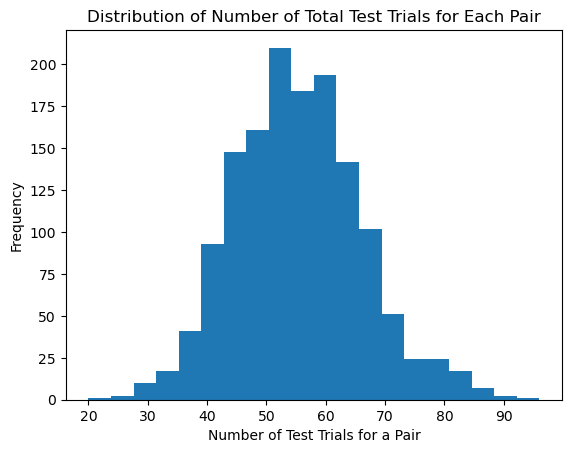

In [20]:
plt.hist(upper(counterUpper_all), bins=20)
plt.xlabel('Number of Test Trials for a Pair')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Total Test Trials for Each Pair')
plt.show()

### Reorder based on hierarchical clustering

In [21]:
np.fill_diagonal(dMat_all.values, 0)
dMat_all.values

array([[0.        , 0.33333333, 0.85714286, ..., 0.56756757, 0.77777778,
        0.75806452],
       [0.33333333, 0.        , 0.78461538, ..., 0.73214286, 0.71014493,
        0.72580645],
       [0.85714286, 0.78461538, 0.        , ..., 0.79104478, 0.37313433,
        0.73684211],
       ...,
       [0.56756757, 0.73214286, 0.79104478, ..., 0.        , 0.66666667,
        0.69354839],
       [0.77777778, 0.71014493, 0.37313433, ..., 0.66666667, 0.        ,
        0.5       ],
       [0.75806452, 0.72580645, 0.73684211, ..., 0.69354839, 0.5       ,
        0.        ]])

In [22]:
def get_action(name):
    return name.split("_", 1)[1]

In [23]:
row_actions = dMat_all.index.map(get_action)
col_actions = dMat_all.columns.map(get_action)
df_row_avg = dMat_all.groupby(row_actions).mean()
human27 = df_row_avg

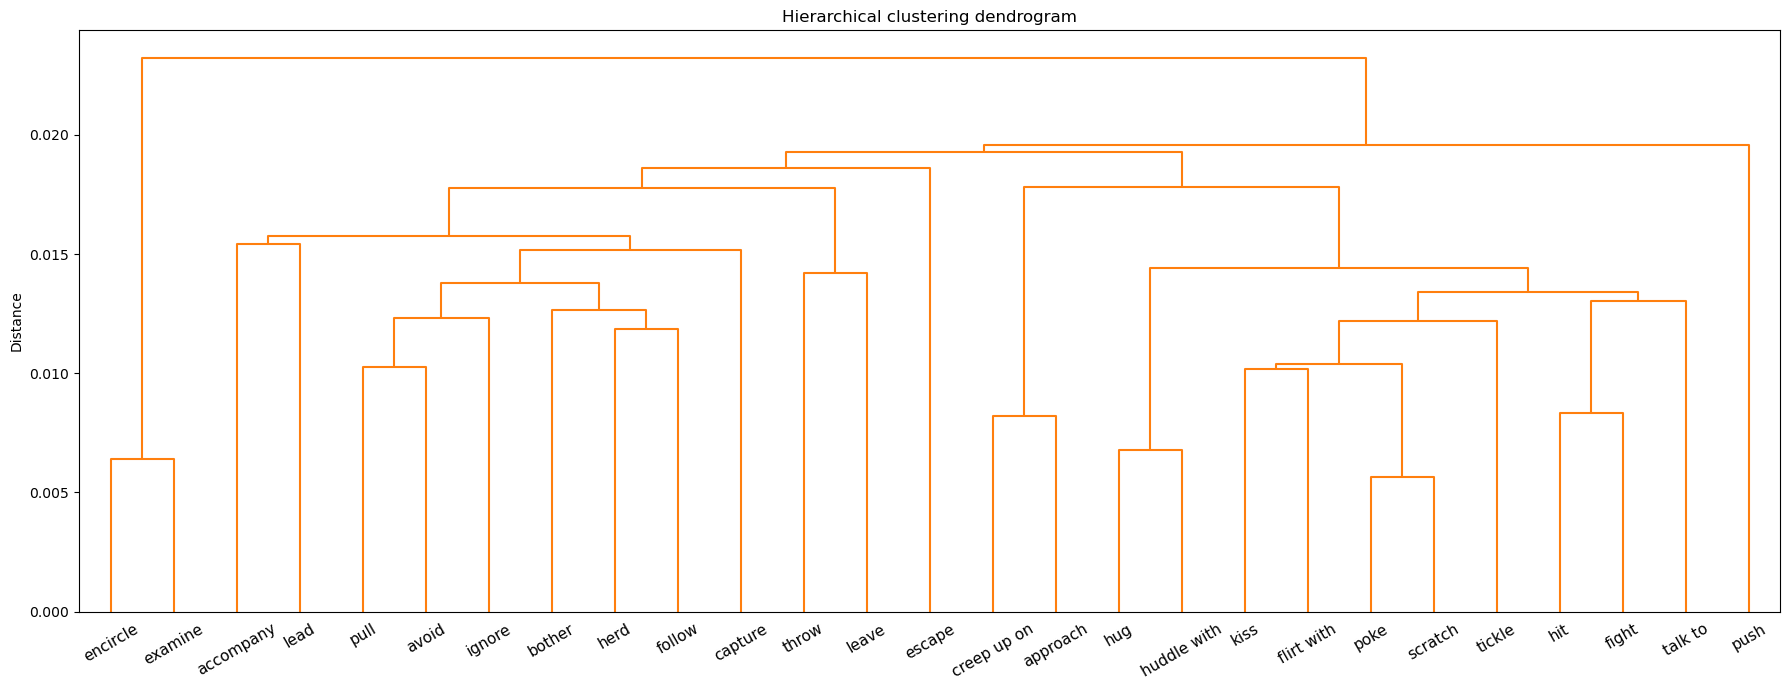

In [24]:
# 1) Choose a distance + linkage method
# Common: metric="euclidean" with method="ward" (good for continuous features)
# If you have correlation-like similarity, try metric="correlation" + method="average"
metric = "cosine" #"correlation" #"euclidean"
method = "single" #"ward" #"average"

# SciPy linkage can take X directly for many cases, but pdist makes it explicit:
D = pdist(human27, metric=metric)          # condensed distance vector
Z = linkage(D, method=method, optimal_ordering=True)        # hierarchical clustering

# 2) Pick a cut height (the dashed line)
cut_height = 0.28  # <-- adjust to get your desired number of clusters

# 3) Plot dendrogram
fig, ax = plt.subplots(figsize=(18, 7))
d = dendrogram(
    Z,
    labels=human27.index,
    leaf_rotation=30,     # rotate x labels like your figure
    leaf_font_size=11,
    color_threshold=cut_height,  # colors branches below this height
    above_threshold_color="0.5"  # gray above threshold
)
ordered_labels_hc = d["ivl"]

ax.axhline(cut_height, ls="--", lw=1.5, color="0.5")
ax.set_ylabel("Distance")
ax.set_title("Hierarchical clustering dendrogram")
plt.tight_layout()
plt.show()

In [25]:
ordered_labels_hc

['encircle',
 'examine',
 'accompany',
 'lead',
 'pull',
 'avoid',
 'ignore',
 'bother',
 'herd',
 'follow',
 'capture',
 'throw',
 'leave',
 'escape',
 'creep up on',
 'approach',
 'hug',
 'huddle with',
 'kiss',
 'flirt with',
 'poke',
 'scratch',
 'tickle',
 'hit',
 'fight',
 'talk to',
 'push']

In [26]:
def get_reordered_df(df, order):
    action_rank = {a: i for i, a in enumerate(order)}

    row_sort_idx = sorted(
        range(len(df.index)),
        key=lambda i: action_rank[row_actions[i]]
    )

    col_sort_idx = sorted(
        range(len(df.columns)),
        key=lambda i: action_rank[col_actions[i]]
    )

    reordered_df = df.iloc[row_sort_idx, col_sort_idx]
    return reordered_df

In [27]:
human54 = get_reordered_df(dMat_all, ordered_labels_hc)
human54

,6017_encircle,5905_encircle,5991_examine,5788_examine,5787_accompany,6300_accompany,4408_lead,4926_lead,5809_pull,6239_pull,...,5914_tickle,1104_tickle,5902_hit,6172_hit,5986_fight,6026_fight,5814_talk to,6013_talk to,1012_push,5568_push
6017_encircle,0.000000,0.288136,0.415094,0.380000,0.687500,0.685185,0.750000,0.835616,0.825397,0.785714,...,0.769231,0.870968,0.666667,0.815789,0.826667,0.724138,0.704918,0.872340,0.900000,0.780488
5905_encircle,0.288136,0.000000,0.510204,0.245283,0.480000,0.687500,0.730159,0.786517,0.866667,0.736842,...,0.678161,0.833333,0.620690,0.770492,0.830769,0.844444,0.725806,0.666667,0.849057,0.844828
5991_examine,0.415094,0.510204,0.000000,0.382979,0.660000,0.641026,0.767857,0.576923,0.826923,0.818182,...,0.666667,0.847458,0.784615,0.783333,0.781250,0.791667,0.652174,0.701754,0.744186,0.818182
5788_examine,0.380000,0.245283,0.382979,0.000000,0.500000,0.612903,0.711864,0.779661,0.823529,0.892308,...,0.696429,0.679245,0.644444,0.800000,0.859649,0.734375,0.716981,0.711538,0.910714,0.760000
5787_accompany,0.687500,0.480000,0.660000,0.500000,0.000000,0.333333,0.436364,0.655172,0.450000,0.640000,...,0.777778,0.758065,0.836735,0.708333,0.826087,0.720588,0.818182,0.618182,0.636364,0.693878
6300_accompany,0.685185,0.687500,0.641026,0.612903,0.333333,0.000000,0.365079,0.396825,0.553571,0.653846,...,0.710145,0.725806,0.843137,0.745763,0.768293,0.775862,0.729167,0.574074,0.655172,0.723404
4408_lead,0.750000,0.730159,0.767857,0.711864,0.436364,0.365079,0.000000,0.478261,0.578125,0.469388,...,0.795455,0.704545,0.716981,0.837209,0.773585,0.712121,0.875000,0.617021,0.514286,0.705882
4926_lead,0.835616,0.786517,0.576923,0.779661,0.655172,0.396825,0.478261,0.000000,0.603175,0.384615,...,0.756410,0.631579,0.657895,0.644444,0.812500,0.560606,0.833333,0.666667,0.656250,0.548387
5809_pull,0.825397,0.866667,0.826923,0.823529,0.450000,0.553571,0.578125,0.603175,0.000000,0.421053,...,0.829268,0.781818,0.839286,0.754098,0.837209,0.738462,0.916667,0.675000,0.686275,0.704918
6239_pull,0.785714,0.736842,0.818182,0.892308,0.640000,0.653846,0.469388,0.384615,0.421053,0.000000,...,0.711111,0.693548,0.756757,0.666667,0.771930,0.714286,0.767857,0.836066,0.600000,0.625000


In [28]:
# human54.to_csv(f"full_dmat_585subj_hcordered.csv", sep = "\t")

In [29]:
# orderedVideosAfterHC = human54.columns
# with open("../../../utils/video_order_from_hc_human_dmat.txt", "w") as f:
#     f.write("\n".join(orderedVideosAfterHC))

## Visualize distance matrix

In [30]:
def draw_dist_mat(dMat, title, palette = "magma", save=False):
    np.fill_diagonal(dMat.values, 0)
    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(13, 10))

    # Generate a custom diverging colormap
    cmap = sns.color_palette(palette, as_cmap=True) #turbo coolwarm_r 

    # Draw the heatmap with the mask and correct aspect ratio
    ax=sns.heatmap(dMat, cmap=cmap, xticklabels=list(dMat.columns), yticklabels=list(dMat.index),
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},)
    cbar=ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=20)

    # plt.tick_params(axis="both", labelsize=10)
    n = len(dMat.columns)
    if title == "study2_human_mat_dpi900":
        verbs = [v.split("_", 1)[1] for v in dMat.columns]
        verb_labels = verbs[::2]   # length = 27

        tick_positions = np.arange(0, n, 2) + 1

        ax.set_xticks(tick_positions)
        ax.set_yticks(tick_positions)

        ax.set_xticklabels(verb_labels, rotation=90)
        ax.set_yticklabels(verb_labels)

    else:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=20, weight="bold")
        
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    ax.invert_yaxis()
    ax.spines[['left', 'bottom']].set_color('black')
    plt.show()
    if save:
        f.savefig(title + '.pdf', bbox_inches='tight', dpi = 900)

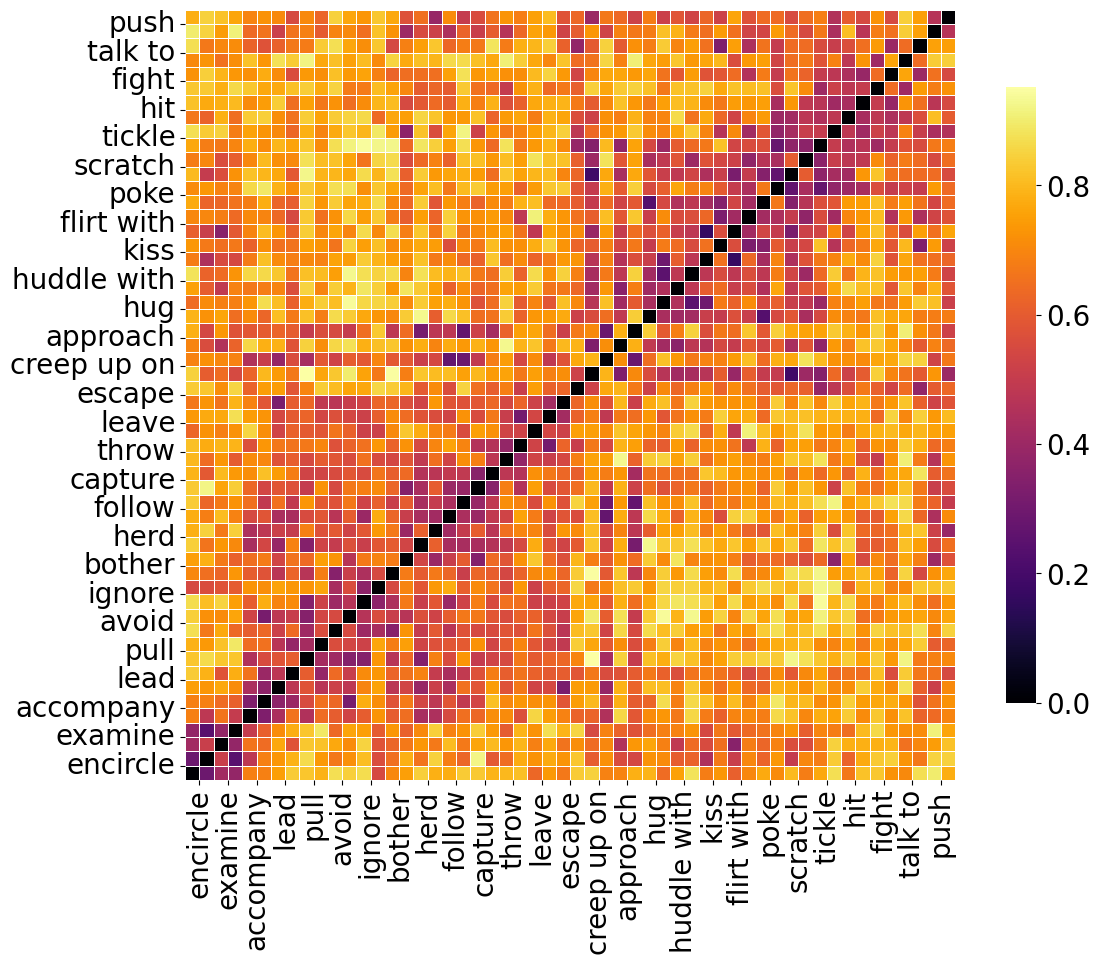

In [31]:
draw_dist_mat(human54, "study2_human_mat_dpi900", palette="inferno", save = True) 

## Test reliability

In [32]:
numOfRep = 500 #completed under 10min
corrListFromSplitHalf = []
pListFromSplitHalf = []
for i in range(numOfRep):
    [corr, p] = get_corr_from_one_splithalf(i, cleanedTrial, orderedVideos)
    corrListFromSplitHalf.append(corr)
    pListFromSplitHalf.append(p)

/var/folders/k7/mm5crvhx3210xfdblpr8gzsw0000gn/T/ipykernel_13014/1532367184.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, y, 'k', color='#CC4F1B')


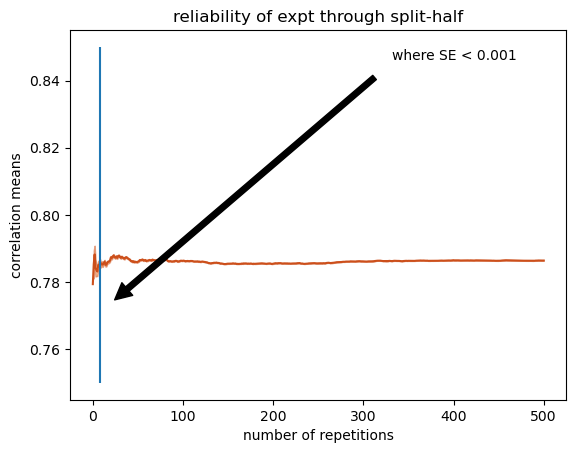

In [33]:
x = np.linspace(0, numOfRep, numOfRep)
y = pd.DataFrame(corrListFromSplitHalf).expanding().mean()[0]
error = pd.DataFrame(corrListFromSplitHalf).expanding().std()[0] / range(1, numOfRep+1)

plt.plot(x, y, 'k', color='#CC4F1B')
plt.xlabel("number of repetitions")
plt.ylabel("correlation means")
plt.title("reliability of expt through split-half")
plt.vlines(error[error < 0.001].index[0], ymin = 0.75, ymax = 0.85)
plt.annotate('where SE < 0.001', xy=(error[error < 0.001].index[0], 0.771),  xycoords='data',
            xytext=(0.9, 0.95), textcoords='axes fraction',
            arrowprops=dict(facecolor='black', shrink=0.05),
            horizontalalignment='right', verticalalignment='top',
            )
plt.fill_between(x, y-error, y+error,
    alpha=0.5, edgecolor='#CC4F1B', facecolor='#FF9848')

In [34]:
corr = np.mean(corrListFromSplitHalf)
corr

0.786425408146381

In [35]:
# SB correction
corr_corrected = 2 * corr / (1 + corr)
corr_corrected

0.8804458384438077

In [36]:
np.percentile(corrListFromSplitHalf, [2.5, 97.5])

array([0.76887578, 0.80244244])

In [37]:
ooo_corr_noise_ceiling = corr_corrected
ooo_corr_noise_ceiling

0.8804458384438077

# Correlation with models

## Import distance matrices

In [38]:
def import_dismat_csv(fileName, humanRst=False):
    if humanRst:
        df = pd.read_csv(fileName, sep="\t", header=0, index_col = 0)
    else: 
        df = pd.read_csv(fileName, header=None, index_col=False)
        with open("./../../../utils/video_order_from_hc_human_dmat.txt") as f:
            orderedVideosAfterHC = f.read().splitlines()
        df.columns = orderedVideosAfterHC
        df.index = orderedVideosAfterHC
    return df

In [39]:
human54 = import_dismat_csv("./full_dmat_585subj_hcordered.csv", humanRst=True)
kinaFeat = import_dismat_csv("./../../../models/force/distMat/kinematic_feat_hist_dist.csv")
kinaFeatProjVec = import_dismat_csv("./../../../models/force/distMat/kinematic_feat_hist_dist_with_proj_velocity.csv")
force = import_dismat_csv("./../../../models/force/distMat/force_hist_dist.csv")
histCore = import_dismat_csv("./../../../models/histo_static/distMat/histogram_mlp_kinematic_dist.csv")
histForce = import_dismat_csv("./../../../models/histo_static/distMat/histogram_mlp_force_dist.csv")
lstmCore = import_dismat_csv("./../../../models/lstm/dist_mat/lstm_distr_core.csv")
lstmForce = import_dismat_csv("./../../../models/lstm/dist_mat/lstm_distr_force.csv")
lstmCoreAndForce = import_dismat_csv("./../../../models/lstm/dist_mat/lstm_distr_coreAndForce.csv")

## Visualize model distance matrices

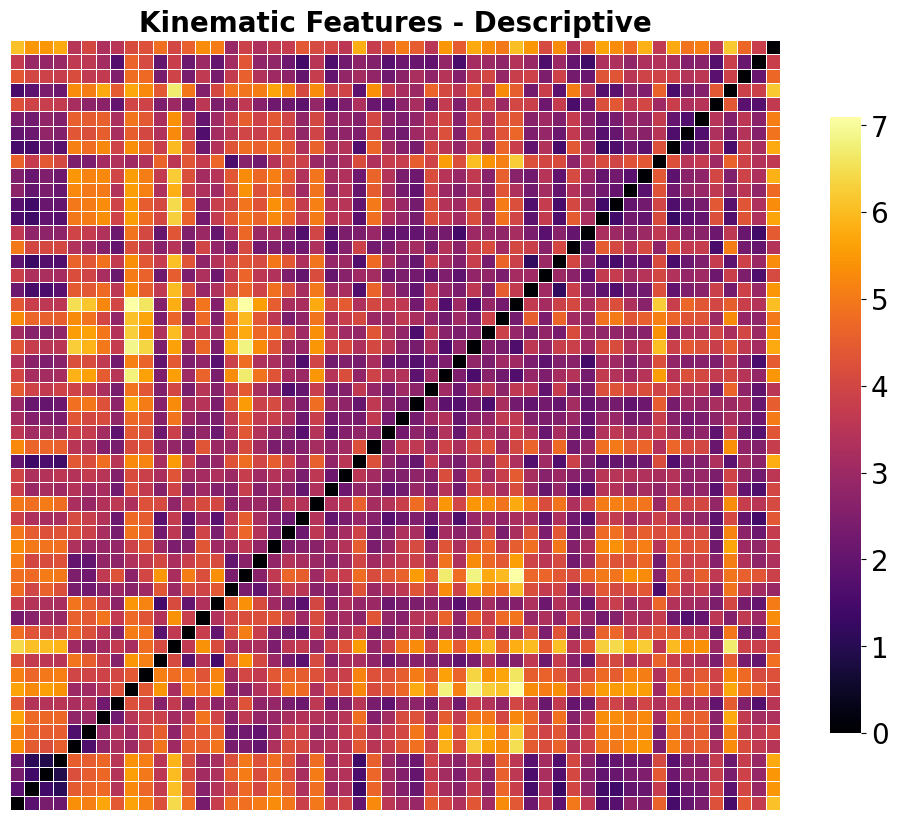

In [40]:
draw_dist_mat(kinaFeat, "Kinematic Features - Descriptive", palette="inferno", save = True)# 

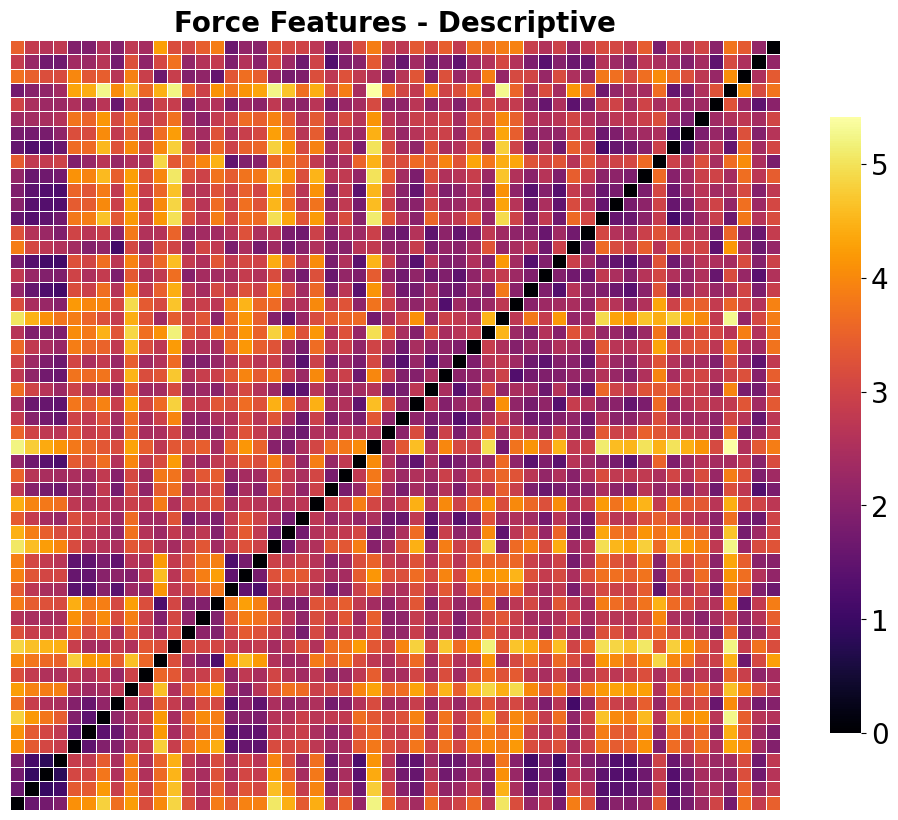

In [41]:
draw_dist_mat(force, "Force Features - Descriptive", palette="inferno", save = True)

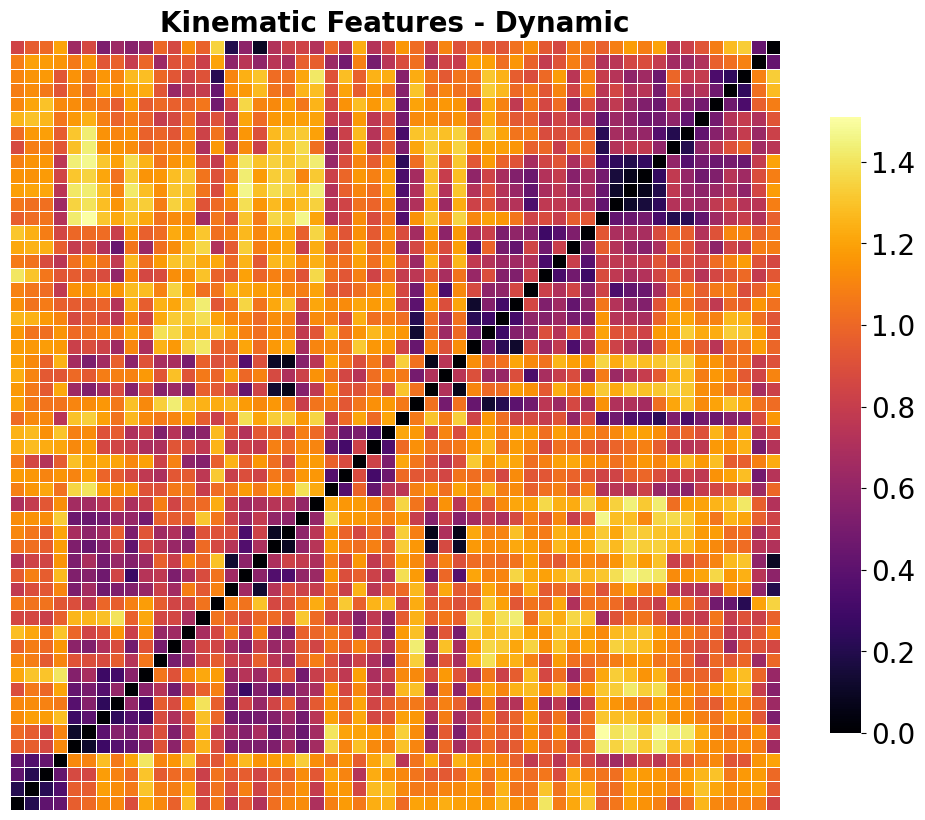

In [42]:
draw_dist_mat(lstmCore, "Kinematic Features - Dynamic", palette="inferno", save =True)

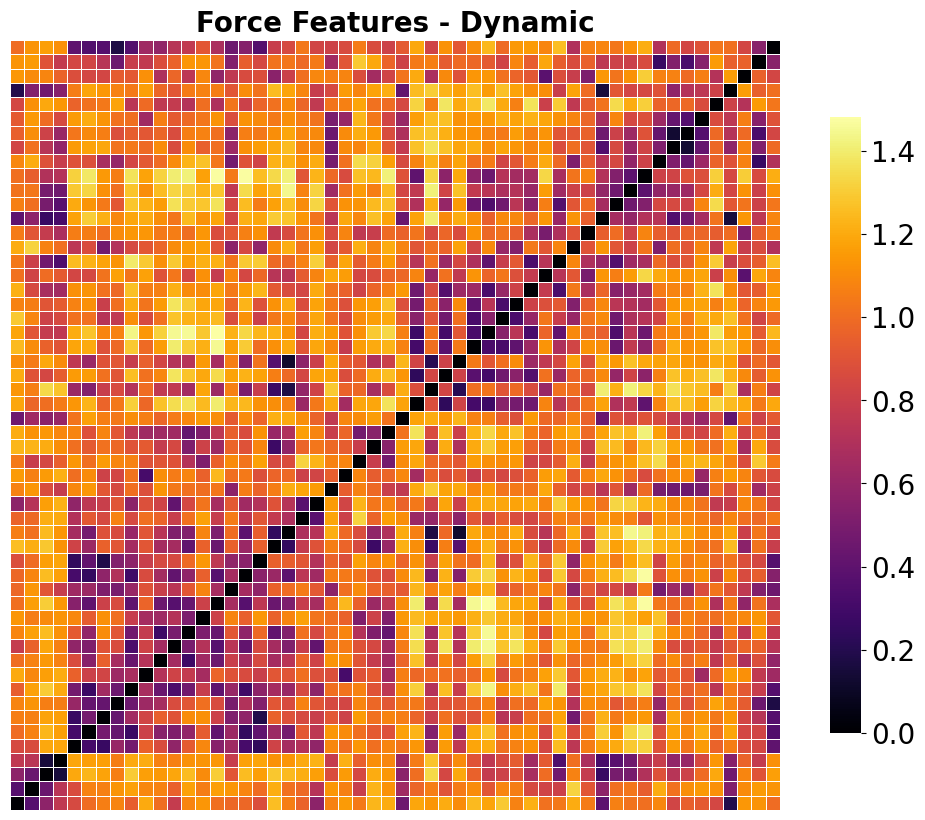

In [43]:
draw_dist_mat(lstmForce, "Force Features - Dynamic", palette="inferno", save = True)

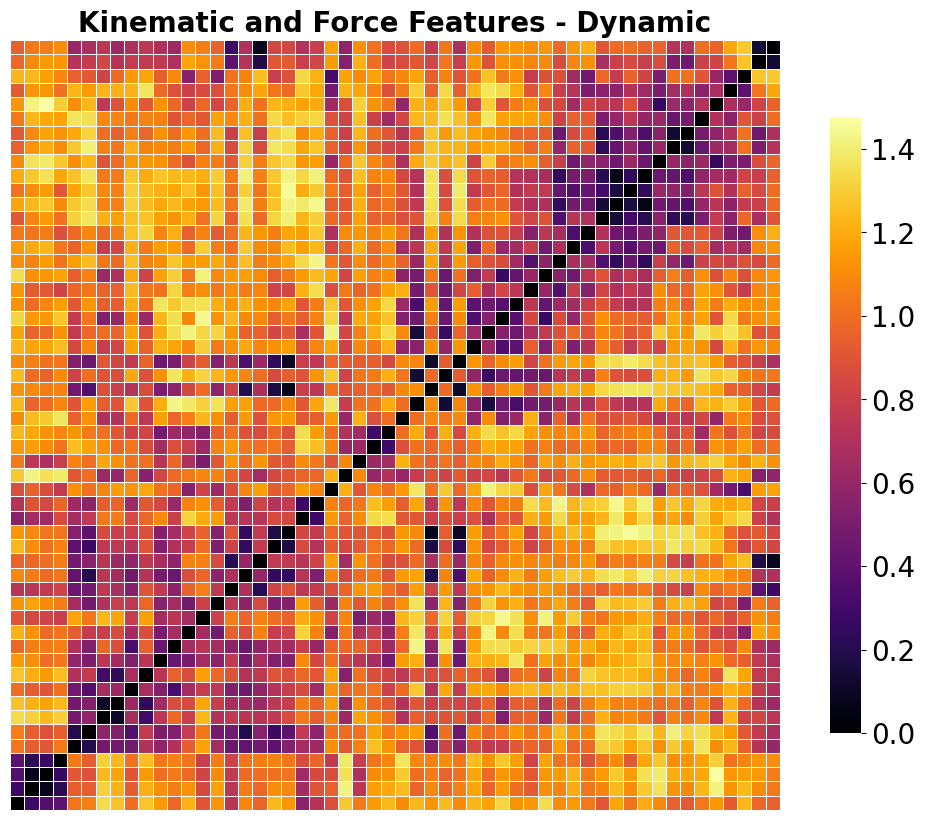

In [44]:
draw_dist_mat(lstmCoreAndForce, "Kinematic and Force Features - Dynamic", palette="inferno", save = True)

## Correlation

In [45]:
models = ["kinaFeat", "kinaFeatProjVec", "force", "histCore", "histForce", "lstmCore", "lstmForce", "lstmCoreAndForce"]
corrDf = pd.DataFrame(index=["human54"], columns=models)
corrPDf = pd.DataFrame(index=["human54"], columns=models)
corrRDf = pd.DataFrame(index=["human54"], columns=models)
for model in corrDf.columns:
    for rst in corrDf.index:
        corrDf.loc[rst, model] = get_spearmanCorrAndP(eval(rst), eval(model))[0]
        corrPDf.loc[rst, model] = get_spearmanCorrAndP(eval(rst), eval(model))[1]

In [46]:
corrDf

,kinaFeat,kinaFeatProjVec,force,histCore,histForce,lstmCore,lstmForce,lstmCoreAndForce
human54,0.325682,0.298421,0.359482,0.525655,0.524459,0.563719,0.556671,0.61229


In [47]:
exptCorr = corrDf.loc["human54", ["kinaFeat", "force", "lstmCore", "lstmForce", "lstmCoreAndForce"]]
exptCorr 

kinaFeat            0.325682
force               0.359482
lstmCore            0.563719
lstmForce           0.556671
lstmCoreAndForce     0.61229
Name: human54, dtype: object

In [48]:
exptP = corrPDf.loc["human54", ["kinaFeat", "force", "lstmCore", "lstmForce", "lstmCoreAndForce"]]
exptP

kinaFeat            0.0
force               0.0
lstmCore            0.0
lstmForce           0.0
lstmCoreAndForce    0.0
Name: human54, dtype: object

In [49]:
exptsig = ["***" if x <= 0.001 else "**" if x <= 0.01 else "*" if x <= 0.05 else "" for x in exptP]
exptsig

['***', '***', '***', '***', '***']

In [50]:
ooo_corr_noise_ceiling = 0.8804458384438077

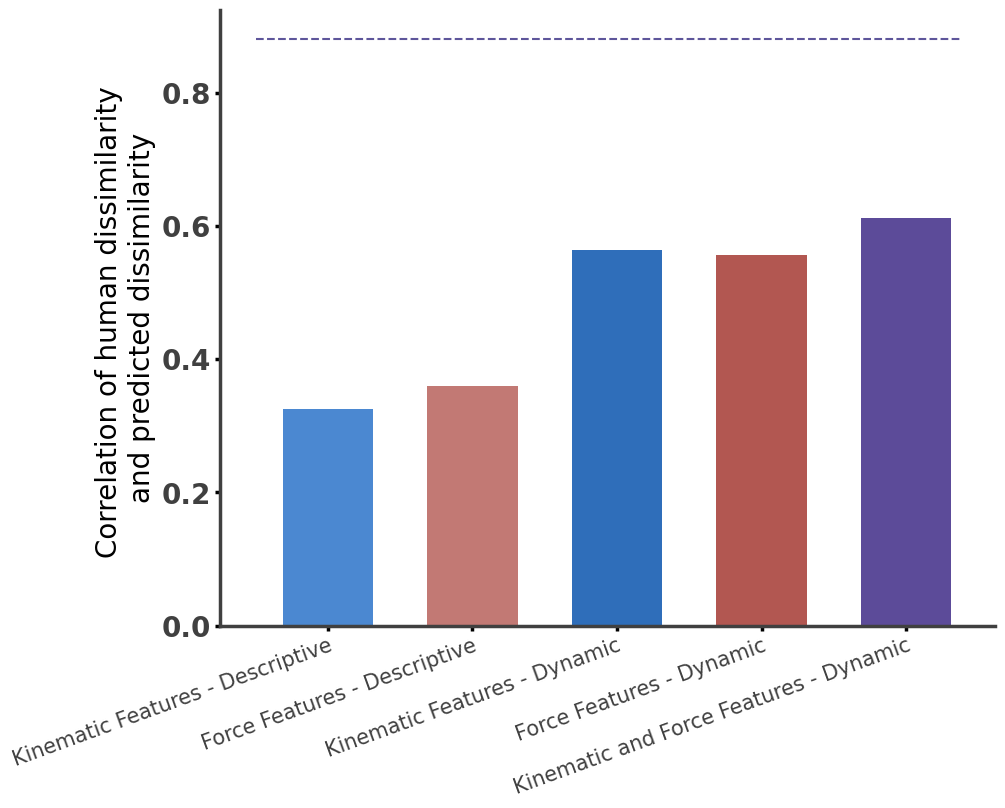

In [51]:
# title = "Accuracy of Predicted Odd-one-out Responses Compared to Human"
title = "Model Comparison"
f, ax = plt.subplots(figsize=(10, 8))
n = len(exptCorr)
r = np.arange(n) * 8
width = 5
my_colors = ['#4B88D1', "#c27974", "#2f6eba", "#b25751", "#5C4B99"] #"#e07b39" "#f5be53 "#5C4B99"

x = ["Kinematic Features - Descriptive", "Force Features - Descriptive", "Kinematic Features - Dynamic", "Force Features - Dynamic", "Kinematic and Force Features - Dynamic"]
plt.bar(r, exptCorr, color=my_colors, label='Experiment 1', width = width)
plt.hlines(ooo_corr_noise_ceiling, linestyle="dashed", color = ["#5e569b"], xmin = -4, xmax = 35)
ax.set_ylabel("Correlation of human dissimilarity \nand predicted dissimilarity", fontsize=20)
plt.xticks(r, x, rotation = 20, ha='right', rotation_mode='anchor')
for spine in plt.gca().spines.values():
    spine.set_linewidth(2.5)
plt.tick_params(axis="both", labelsize=20)
plt.tick_params(axis="x", labelsize=15)
ax.tick_params(width=2.5)
for label in plt.gca().get_yticklabels():
    label.set_fontweight("bold")
    label.set_color('#404040')
for label in plt.gca().get_xticklabels():
    # label.set_fontweight("bold")
    label.set_color('#404040')

ax.spines[['left', 'bottom']].set_color('#404040')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor("white")
# for i, v in enumerate(exptCorr):
#     ax.text(8*i-1, v + 0.01, exptsig[i], color='black', fontsize=20)
f.savefig('study2_human_model_corr.pdf', bbox_inches='tight', dpi = 600)

# Get Odd-One-Out Accuracy

In [52]:
oooResponsesDf = cleanedTrial.copy()

In [53]:
# Function to clean and standardize the options list
def standardize_options(option_list):
    option_list = sorted(option_list)  # Sort to ensure uniqueness
    return str(option_list)  # Convert back to string for comparison

In [54]:
oooResponsesDf["options"] = oooResponsesDf["options"].apply(standardize_options)

## Test reliability

In [55]:
# Inspired by Muttenthaler 2025
def get_triplet_certainty_robust(choices):
    """
    Robust LOO Certainty calculation.
    Handles ties between 2 or 3 options equally.
    """
    choices = list(choices)
    num_choices = len(choices)
    if num_choices <= 1:
        return 1.0
    
    # Optimization: if everyone agrees, certainty is 1
    if len(set(choices)) == 1:
        return 1.0
    
    matches = 0
    for i in range(num_choices):
        loo_choice = choices[i]
        sample = choices[:i] + choices[i+1:]
        
        # Get counts of the remaining group
        counts_dict = Counter(sample)
        max_count = max(counts_dict.values())
        
        # Find ALL choices that share the maximum count
        # This handles 2-way ties AND 3-way ties
        tied_options = [val for val, count in counts_dict.items() if count == max_count]
        
        if loo_choice in tied_options:
            # Reward points based on the size of the tie
            # 1 point if no tie, 0.5 if 2-way tie, 0.33 if 3-way tie
            matches += (1.0 / len(tied_options))
                
    return matches / num_choices

def compute_dataframe_noise_ceiling(df, triplet_col='options', choice_col='choice'):
    """
    The main wrapper to run the calculation on your DataFrame.
    """
    # 1. Calculate certainty for every unique triplet
    # This replaces the nested dictionary loops
    triplet_certainties = df.groupby(triplet_col)[choice_col].apply(get_triplet_certainty_robust)
    
    overall_noise_ceiling = triplet_certainties.mean()
    print(f"\nNoise ceiling across all triplets: {overall_noise_ceiling:.4f}\n")
    return overall_noise_ceiling


In [56]:
ooo_noise_ceiling = compute_dataframe_noise_ceiling(oooResponsesDf)


Noise ceiling across all triplets: 0.7913



## Compare ooo accuracy

In [57]:
oooResponsesDf_choice_list = oooResponsesDf.groupby("options")["choice"].apply(list).reset_index()
oooResponsesDf_choice_list["options"] = oooResponsesDf_choice_list.apply(lambda row: parse_array_from_string(row), axis = 1)
oooResponsesDf_choice_list

,options,choice
0,"[1012_push, 1051_herd, 1167_kiss]",[1012_push]
1,"[1012_push, 1051_herd, 4408_lead]",[4408_lead]
2,"[1012_push, 1051_herd, 4788_capture]",[1012_push]
3,"[1012_push, 1051_herd, 4806_flirt with]",[4806_flirt with]
4,"[1012_push, 1051_herd, 5096_approach]",[1051_herd]
...,...,...
12803,"[6035_capture, 6239_pull, 6300_accompany]",[6239_pull]
12804,"[6058_leave, 6079_bother, 6239_pull]",[6058_leave]
12805,"[6058_leave, 6172_hit, 6300_accompany]",[6058_leave]
12806,"[6058_leave, 6239_pull, 6300_accompany]",[6239_pull]


In [58]:
def generate_model_choice_accuracy(modelDisMat, row): # get distance
    # get choice
    options = row.options

    ab = modelDisMat.loc[options[0], options[1]]
    bc = modelDisMat.loc[options[1], options[2]]
    ac = modelDisMat.loc[options[0], options[2]]

    pairwiseDist = [ab, bc, ac]
    minVal = min(pairwiseDist)
    numMin = pairwiseDist.count(minVal)
    if numMin > 1:
        print("Multiple minimums")

    if ab == minVal:
        modelChoice = options[2]
    elif bc == minVal:
        modelChoice = options[0]
    else:
        modelChoice = options[1]

    # get accuracy
    counts = Counter(row.choice)
    max_votes = max(counts.values())
    
    # Identify the human majority (could be 1, 2, or 3 images)
    human_majority_options = [vid for vid, count in counts.items() if count == max_votes]
    if modelChoice in human_majority_options:
        accuracy = 1/len(human_majority_options)
    else:
        accuracy = 0
    accuracy

    return [modelChoice, accuracy]


In [59]:
oooResponsesDf_choice_list

,options,choice
0,"[1012_push, 1051_herd, 1167_kiss]",[1012_push]
1,"[1012_push, 1051_herd, 4408_lead]",[4408_lead]
2,"[1012_push, 1051_herd, 4788_capture]",[1012_push]
3,"[1012_push, 1051_herd, 4806_flirt with]",[4806_flirt with]
4,"[1012_push, 1051_herd, 5096_approach]",[1051_herd]
...,...,...
12803,"[6035_capture, 6239_pull, 6300_accompany]",[6239_pull]
12804,"[6058_leave, 6079_bother, 6239_pull]",[6058_leave]
12805,"[6058_leave, 6172_hit, 6300_accompany]",[6058_leave]
12806,"[6058_leave, 6239_pull, 6300_accompany]",[6239_pull]


In [60]:
oooResponsesDf_choice_list[["kinaFeatHistChoice", "kinaFeatHistAcc"]] = oooResponsesDf_choice_list.apply(lambda row: generate_model_choice_accuracy(kinaFeat, row), axis = 1, result_type = "expand")
oooResponsesDf_choice_list[["forceHistChoice", "forceHistAcc"]] = oooResponsesDf_choice_list.apply(lambda row: generate_model_choice_accuracy(force, row), axis = 1, result_type = "expand")
oooResponsesDf_choice_list[["histCoreChoice", "histCoreAcc"]] = oooResponsesDf_choice_list.apply(lambda row: generate_model_choice_accuracy(histCore, row), axis = 1, result_type = "expand")
oooResponsesDf_choice_list[["histForceChoice", "histForceAcc"]] = oooResponsesDf_choice_list.apply(lambda row: generate_model_choice_accuracy(histForce, row), axis = 1, result_type = "expand")
oooResponsesDf_choice_list[["lstmCoreChoice", "lstmCoreAcc"]] = oooResponsesDf_choice_list.apply(lambda row: generate_model_choice_accuracy(lstmCore, row), axis = 1, result_type = "expand")
oooResponsesDf_choice_list[["lstmForceChoice", "lstmForceAcc"]] = oooResponsesDf_choice_list.apply(lambda row: generate_model_choice_accuracy(lstmForce, row), axis = 1, result_type = "expand")
oooResponsesDf_choice_list[["lstmCoreAndForceChoice", "lstmCoreAndForceAcc"]] = oooResponsesDf_choice_list.apply(lambda row: generate_model_choice_accuracy(lstmCoreAndForce, row), axis = 1, result_type = "expand")

## Draw graph

In [61]:
ooo_mean = oooResponsesDf_choice_list.loc[:,["kinaFeatHistAcc", "forceHistAcc", "histCoreAcc", "histForceAcc", "lstmCoreAcc", "lstmForceAcc", "lstmCoreAndForceAcc"]].mean()
ooo_mean

kinaFeatHistAcc        0.402014
forceHistAcc           0.405996
histCoreAcc            0.439608
histForceAcc           0.441092
lstmCoreAcc            0.448392
lstmForceAcc           0.440467
lstmCoreAndForceAcc    0.455340
dtype: float64

In [62]:
ooo_sem = oooResponsesDf_choice_list.loc[:,["kinaFeatHistAcc", "forceHistAcc", "histCoreAcc", "histForceAcc", "lstmCoreAcc", "lstmForceAcc", "lstmCoreAndForceAcc"]].sem()
ooo_sem

kinaFeatHistAcc        0.004117
forceHistAcc           0.004118
histCoreAcc            0.004160
histForceAcc           0.004159
lstmCoreAcc            0.004164
lstmForceAcc           0.004157
lstmCoreAndForceAcc    0.004171
dtype: float64

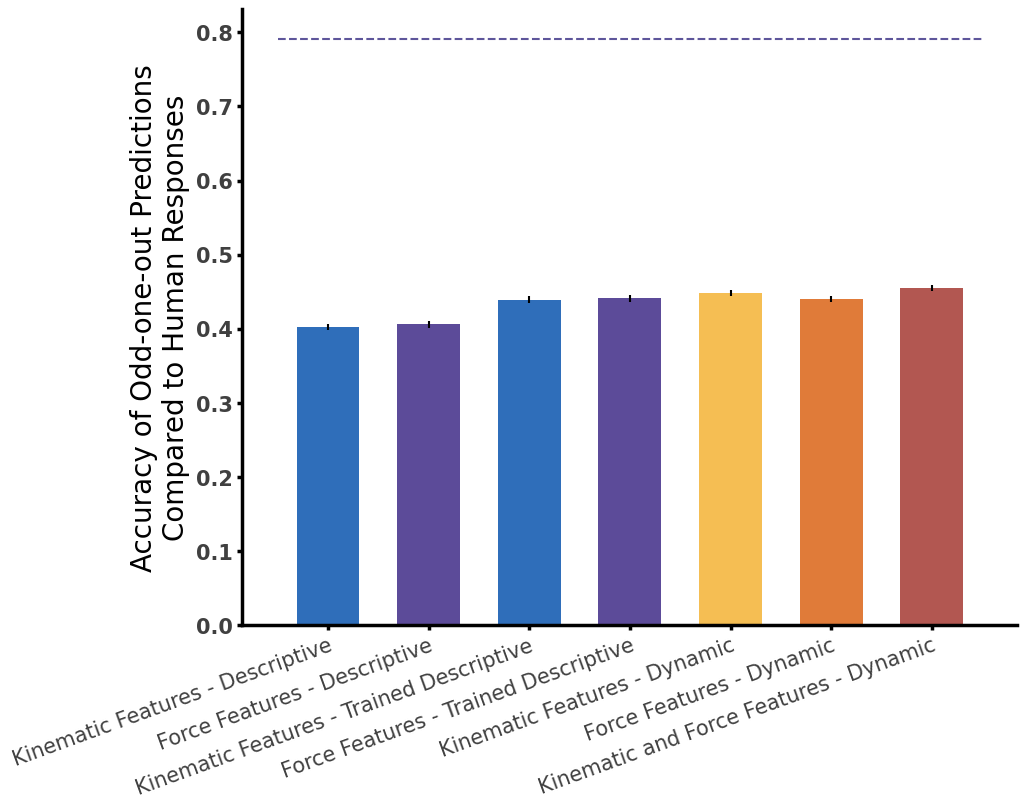

In [63]:
title = "Accuracy of Predicted Odd-one-out Responses Compared to Human"
f, ax = plt.subplots(figsize=(10, 8))
n = len(ooo_mean)
r = np.arange(n) * 8
width = 5
my_colors = ['#2f6eba', "#5C4B99", '#2f6eba', "#5C4B99", "#f5be53", "#e07b39", "#b25751"]

x = ["Kinematic Features - Descriptive", "Force Features - Descriptive", "Kinematic Features - Trained Descriptive", "Force Features - Trained Descriptive", "Kinematic Features - Dynamic", "Force Features - Dynamic", "Kinematic and Force Features - Dynamic"]
plt.bar(r, ooo_mean, yerr=ooo_sem.values, color = my_colors, label='Experiment 1', width = width)
plt.hlines(ooo_noise_ceiling, linestyle="dashed", color = ["#5e569b"], xmin = -4, xmax = 52)
ax.set_ylabel("Accuracy of Odd-one-out Predictions\nCompared to Human Responses", {'fontsize': 20})
plt.xticks(r, x, rotation = 20, ha='right', rotation_mode='anchor')
for spine in plt.gca().spines.values():
    spine.set_linewidth(2.5)
plt.tick_params(axis="both", labelsize=20)
plt.tick_params(axis="x", labelsize=15)
ax.tick_params(width=2.5)
for label in plt.gca().get_yticklabels():
    label.set_fontweight("bold")
    label.set_color('#404040')
for label in plt.gca().get_xticklabels():
    # label.set_fontweight("bold")
    label.set_color('#404040')

plt.yticks(fontsize=15)
ax.spines[['left', 'bottom']].set_color('#404040')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines[['left', 'bottom']].set_color('black')
ax.set_facecolor("white")
# f.savefig('study2_human_model_ooo_acc.png', bbox_inches='tight', dpi = 300)

# Partialing

In [64]:
l = ["human54", 
     "kinaFeat", "force", "histCore", "histForce", "lstmCore", "lstmForce", "lstmCoreAndForce"]

In [65]:
distDF = pd.DataFrame({i: upper(eval(i)) for i in l})
distDF

,human54,kinaFeat,force,histCore,histForce,lstmCore,lstmForce,lstmCoreAndForce
0,0.288136,1.826778,1.607163,0.086838,0.103042,0.203437,0.366592,0.287788
1,0.415094,2.370984,1.744132,0.113196,0.213661,0.408396,0.571264,0.349483
2,0.380000,2.159410,1.913449,0.102414,0.206764,0.426314,0.754026,0.389509
3,0.687500,5.337273,4.093409,0.394975,0.416283,0.962535,0.855392,1.023496
4,0.685185,5.106744,4.107161,0.330828,0.616624,1.013669,0.996858,1.056363
...,...,...,...,...,...,...,...,...
1426,0.838235,3.850567,3.128101,0.234038,0.285286,1.030302,0.952929,1.024264
1427,0.844444,6.199703,3.752649,0.474529,0.268977,1.273828,1.009913,1.186213
1428,0.754386,2.082876,2.508588,0.344023,0.484567,1.091873,0.956279,1.270702
1429,0.750000,4.695520,3.383229,0.562685,0.541934,1.328140,0.837149,1.291207


In [66]:
pg.partial_corr(data = distDF, x="lstmForce",y="human54", y_covar=["histForce"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.272878,"[0.22, 0.32]",7.765029e-26


In [67]:
pg.partial_corr(data = distDF, x="histForce",y="human54", y_covar=["lstmForce"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.189849,"[0.14, 0.24]",4.525476e-13


In [68]:
pg.partial_corr(data = distDF, x="histCore",y="human54", y_covar=["lstmCore"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.240624,"[0.19, 0.29]",2.777000e-20


In [69]:
pg.partial_corr(data = distDF, x="lstmCore",y="human54", y_covar=["histCore"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.363308,"[0.32, 0.41]",7.378517e-46


In [70]:
pg.partial_corr(data = distDF, x="lstmCore",y="human54", y_covar=["kinaFeat"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.535609,"[0.5, 0.57]",5.677547e-107


In [71]:
pg.partial_corr(data = distDF, x="lstmForce",y="human54", y_covar=["force"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.455138,"[0.41, 0.5]",4.867141e-74


In [72]:
pg.partial_corr(data = distDF, x="kinaFeat",y="human54", y_covar=["lstmCore"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.199464,"[0.15, 0.25]",2.681546e-14


In [73]:
pg.partial_corr(data = distDF, x="force",y="human54", y_covar=["lstmForce"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.152229,"[0.1, 0.2]",7.238715e-09


In [74]:
pg.partial_corr(data = distDF, x="force",y="human54", y_covar=["kinaFeat"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.096336,"[0.04, 0.15]",0.000264


In [75]:
pg.partial_corr(data = distDF, x="lstmForce",y="human54", y_covar=["lstmCore"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.24349,"[0.19, 0.29]",9.584142e-21


In [76]:
pg.partial_corr(data = distDF, x="kinaFeat",y="human54", y_covar=["force"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.057598,"[0.01, 0.11]",0.029407


In [77]:
pg.partial_corr(data = distDF, x="lstmCore",y="human54", y_covar=["lstmForce"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.299872,"[0.25, 0.35]",4.229867e-31


In [78]:
pg.partial_corr(data = distDF, x="lstmCoreAndForce",y="human54", y_covar=["lstmForce", "lstmCore"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.150724,"[0.1, 0.2]",1.031611e-08


In [79]:
pg.partial_corr(data = distDF, x="lstmCore",y="human54", y_covar=["lstmCoreAndForce"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.137602,"[0.09, 0.19]",1.753077e-07


In [80]:
pg.partial_corr(data = distDF, x="lstmForce",y="human54", y_covar=["lstmCoreAndForce"], method = "pearson")

,n,r,CI95%,p-val
pearson,1431,0.205408,"[0.16, 0.25]",4.344168e-15
